# MScFE 600: Financial Data — Group Work Project #1
## Part 1 Replication: ECH ETF Technical Indicator Analysis
**Group Number: 14434**  
**Members: Oluwatobi Dahunsi, Abhishek Sharma, Sarafa Busari**  
**Sample Period: January 1, 2010 – December 31, 2023**  

This notebook supports the replication section (Step 3) of GWP #1.  
It downloads ECH ETF data, computes five technical indicators, defines a binary classification target,  
runs Pearson correlation analysis, performs 5-fold cross-validation with logistic regression, and  
produces two charts for inclusion in the written report.

## 0. Install and Import Libraries

In [2]:
# Install yfinance if not already present
!pip install yfinance --quiet

import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 10)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Download ECH ETF Data
We use `yfinance` to download daily OHLCV data for the iShares MSCI Chile ETF (ECH).  
The `auto_adjust=True` flag ensures that the 'Close' column reflects split- and dividend-adjusted prices.

In [3]:
TICKER = 'ECH'
START  = '2010-01-01'
END    = '2023-12-31'

raw = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)

# Handle MultiIndex columns that newer yfinance versions may return
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
df.index = pd.to_datetime(df.index)

print(f'Ticker           : {TICKER}')
print(f'Period           : {df.index[0].date()} to {df.index[-1].date()}')
print(f'Trading days     : {len(df)}')
print(f'First close price: {df["Close"].iloc[0]:.4f} USD')
print(f'Last close price : {df["Close"].iloc[-1]:.4f} USD')
print()
print('Sample rows (first 5):')
print(df.head())

Ticker           : ECH
Period           : 2010-01-04 to 2023-12-29
Trading days     : 3522
First close price: 37.6557 USD
Last close price : 26.7425 USD

Sample rows (first 5):
Price         Open    High     Low   Close  Volume
Date                                              
2010-01-04 37.3000 37.7900 36.9308 37.6557   91800
2010-01-05 37.8303 37.9578 37.6557 37.8101  122300
2010-01-06 38.1055 38.4814 38.0182 38.4209  118500
2010-01-07 38.4075 39.3204 38.3605 39.3204  653300
2010-01-08 39.4009 39.9044 39.2197 39.8574  336000


## 2. Compute Technical Indicators
We compute five standard technical indicators from the OHLCV price data:
- **SMA14_norm**: 14-day Simple Moving Average, normalized as (Close - SMA14) / SMA14
- **RSI14**: 14-day Relative Strength Index
- **BB_Width**: 20-day Bollinger Band Width = 2 * rolling std / rolling mean
- **ATR14**: 14-day Average True Range
- **ROC10**: 10-day Rate of Change (%)

In [4]:
# SMA14 and normalized version
df['SMA14']      = df['Close'].rolling(14).mean()
df['SMA14_norm'] = (df['Close'] - df['SMA14']) / df['SMA14']

# RSI14
def rsi(series, w=14):
    d = series.diff()
    g = d.clip(lower=0).rolling(w).mean()
    l = (-d.clip(upper=0)).rolling(w).mean()
    rs = g / (l + 1e-10)
    return 100 - 100 / (1 + rs)

df['RSI14'] = rsi(df['Close'], 14)

# Bollinger Band Width (20-day)
df['BB_mid']   = df['Close'].rolling(20).mean()
df['BB_std']   = df['Close'].rolling(20).std()
df['BB_Width'] = 2 * df['BB_std'] / df['BB_mid']

# ATR14
df['HL']  = df['High'] - df['Low']
df['HPC'] = (df['High'] - df['Close'].shift(1)).abs()
df['LPC'] = (df['Low']  - df['Close'].shift(1)).abs()
df['TR']  = df[['HL','HPC','LPC']].max(axis=1)
df['ATR14'] = df['TR'].rolling(14).mean()

# ROC10
df['ROC10'] = df['Close'].pct_change(10) * 100

print('Indicators computed. Sample (last 5 rows):')
cols_show = ['Close','SMA14_norm','RSI14','BB_Width','ATR14','ROC10']
print(df[cols_show].tail(5).round(4))

Indicators computed. Sample (last 5 rows):
Price        Close  SMA14_norm   RSI14  BB_Width  ATR14   ROC10
Date                                                           
2023-12-22 26.0979      0.0032 58.1834    0.0481 0.5608  1.2901
2023-12-26 26.3917      0.0115 60.4737    0.0460 0.5616  4.8850
2023-12-27 26.3917      0.0088 59.6690    0.0445 0.5862  3.8739
2023-12-28 26.6193      0.0152 58.5292    0.0432 0.5864  0.6995
2023-12-29 26.7425      0.0171 59.6474    0.0428 0.6021 -0.6402


## 3. Define Binary Target Variable
The target is +1 if the **next trading day** adjusted close is higher than the current day's close, and -1 otherwise.  
This matches the classification formulation used in Sagaceta Mejia et al. (2022).

In [5]:
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, -1)

FEATURES = ['SMA14_norm', 'RSI14', 'BB_Width', 'ATR14', 'ROC10']

# Keep only rows with all features and target defined
df_m = df[FEATURES + ['Target', 'Close']].dropna()
# Drop last row: last row's Target used shift(-1) which wraps to itself
df_m = df_m.iloc[:-1].copy()

n_total  = len(df_m)
n_up     = (df_m['Target'] == 1).sum()
n_down   = (df_m['Target'] == -1).sum()
pct_up   = n_up / n_total * 100
pct_down = n_down / n_total * 100

print(f'Observations after cleaning : {n_total}')
print(f'Up days   (+1)              : {n_up} ({pct_up:.1f}%)')
print(f'Down days (-1)              : {n_down} ({pct_down:.1f}%)')

Observations after cleaning : 3502
Up days   (+1)              : 1757 (50.2%)
Down days (-1)              : 1745 (49.8%)


## 4. Descriptive Statistics

In [6]:
print('Descriptive Statistics of Technical Indicators:')
print(df_m[FEATURES].describe().round(4).to_string())

Descriptive Statistics of Technical Indicators:
Price  SMA14_norm     RSI14  BB_Width     ATR14     ROC10
count   3502.0000 3502.0000 3502.0000 3502.0000 3502.0000
mean      -0.0005   50.1840    0.0524    0.6078    0.0200
std        0.0329   17.9475    0.0308    0.2414    5.0667
min       -0.2859    0.1550    0.0113    0.2867  -37.9910
25%       -0.0192   37.1827    0.0330    0.4521   -3.0171
50%        0.0004   49.8167    0.0462    0.5522    0.1295
75%        0.0198   63.7155    0.0632    0.6923    3.0627
max        0.1525   96.5307    0.3347    2.4816   27.6280


## 5. Pearson Correlation Analysis
We compute the linear (Pearson) correlation between each technical indicator and the binary target variable.  
This is Table 1 in the written report.

In [7]:
corr_vals = df_m[FEATURES].corrwith(df_m['Target'])
corr_df = pd.DataFrame({
    'Feature': FEATURES,
    'Pearson Corr. with Target': corr_vals.values.round(4)
})

print('--- TABLE 1: Pearson Correlation of Features with Target ---')
print(corr_df.to_string(index=False))
print()

best = corr_df.loc[corr_df['Pearson Corr. with Target'].abs().idxmax()]
print(f'Highest absolute correlation: {best["Feature"]} = {best["Pearson Corr. with Target"]}')

--- TABLE 1: Pearson Correlation of Features with Target ---
   Feature  Pearson Corr. with Target
SMA14_norm                     0.0301
     RSI14                     0.0385
  BB_Width                     0.0256
     ATR14                     0.0053
     ROC10                     0.0208

Highest absolute correlation: RSI14 = 0.0385


## 6. 5-Fold Cross-Validation (Logistic Regression Baseline)
We apply stratified 5-fold cross-validation using logistic regression as the baseline classifier.  
Features are standardized within each fold (fit on train, transform on test) to prevent data leakage.  
This is Table 2 in the written report.

In [8]:
X = df_m[FEATURES].values
y = df_m['Target'].values

skf = StratifiedKFold(n_splits=5, shuffle=False)
cv_rows = []

for fold_num, (tr_idx, te_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr_s, y_tr)
    y_pred = clf.predict(X_te_s)

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, pos_label=1)
    cv_rows.append({'Fold': fold_num,
                    'Train Size': len(tr_idx),
                    'Test Size': len(te_idx),
                    'Accuracy': round(acc, 4),
                    'F1-Score': round(f1, 4)})

cv_df = pd.DataFrame(cv_rows)
mean_acc = cv_df['Accuracy'].mean()
mean_f1  = cv_df['F1-Score'].mean()
mean_row = pd.DataFrame([{'Fold':'Mean','Train Size':'-','Test Size':'-',
                           'Accuracy': round(mean_acc,4),'F1-Score': round(mean_f1,4)}])
cv_print = pd.concat([cv_df, mean_row], ignore_index=True)

print('--- TABLE 2: 5-Fold Cross-Validation Results (Logistic Regression) ---')
print(cv_print.to_string(index=False))
print()
print(f'Average Accuracy : {mean_acc:.4f}')
print(f'Average F1-Score : {mean_f1:.4f}')

--- TABLE 2: 5-Fold Cross-Validation Results (Logistic Regression) ---
Fold Train Size Test Size  Accuracy  F1-Score
   1       2801       701    0.5307    0.6389
   2       2801       701    0.5278    0.4361
   3       2802       700    0.5314    0.5205
   4       2802       700    0.5429    0.5543
   5       2802       700    0.4971    0.5665
Mean          -         -    0.5260    0.5433

Average Accuracy : 0.5260
Average F1-Score : 0.5433


## 7. Figure 1 — ECH Adjusted Close Price with 14-Day SMA Overlay
This chart is Figure 1 in the written report. Paste `figure1_ech_sma14.png` into the report.

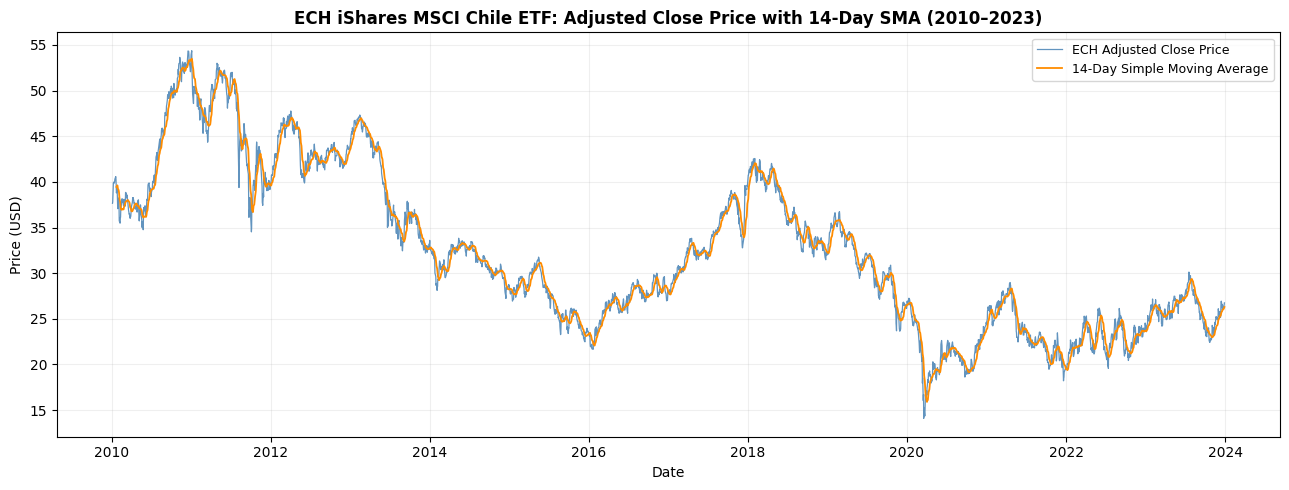

Figure 1 saved: figure1_ech_sma14.png


In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df['Close'],
        label='ECH Adjusted Close Price', color='steelblue', linewidth=0.9, alpha=0.85)
ax.plot(df.index, df['SMA14'],
        label='14-Day Simple Moving Average', color='darkorange', linewidth=1.3)
ax.set_title('ECH iShares MSCI Chile ETF: Adjusted Close Price with 14-Day SMA (2010–2023)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('Price (USD)', fontsize=10)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('figure1_ech_sma14.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved: figure1_ech_sma14.png')

## 8. Figure 2 — ECH 14-Day RSI with Overbought/Oversold Thresholds
This chart is Figure 2 in the written report. Paste `figure2_ech_rsi14.png` into the report.

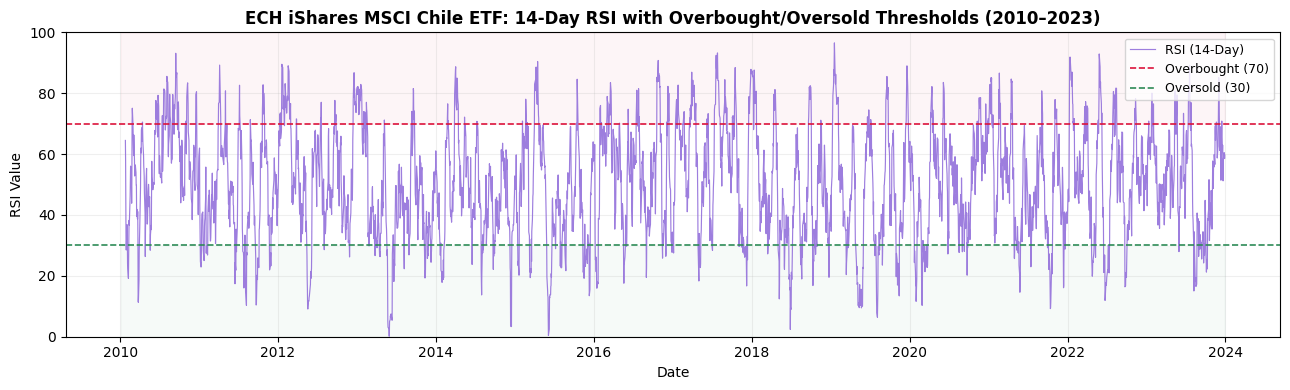

Figure 2 saved: figure2_ech_rsi14.png


In [10]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df.index, df['RSI14'],
        label='RSI (14-Day)', color='mediumpurple', linewidth=0.85, alpha=0.9)
ax.axhline(70, color='crimson',  linestyle='--', linewidth=1.2, label='Overbought (70)')
ax.axhline(30, color='seagreen', linestyle='--', linewidth=1.2, label='Oversold (30)')
ax.fill_between(df.index, 70, 100, alpha=0.04, color='crimson')
ax.fill_between(df.index,  0,  30, alpha=0.04, color='seagreen')
ax.set_title('ECH iShares MSCI Chile ETF: 14-Day RSI with Overbought/Oversold Thresholds (2010–2023)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Date', fontsize=10)
ax.set_ylabel('RSI Value', fontsize=10)
ax.set_ylim(0, 100)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('figure2_ech_rsi14.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved: figure2_ech_rsi14.png')

---
# Part 2: News and Text Data — Python Demonstration
This section demonstrates how to import and structure financial news/text data.  
We use a manually created representative sample to illustrate the workflow,  
since professional datasets (e.g., Refinitiv, RavenPack) require paid access.  
The same workflow applies to any CSV-exported news dataset.

### Step 1: Create Sample News Dataset

In [11]:
# Representative sample of 15 financial news headlines
# Simulates the structure of a real news feed for ECH-relevant events

sample_news = {
    'date': [
        '2023-01-10','2023-01-11','2023-01-12','2023-01-13','2023-01-16',
        '2023-01-17','2023-01-18','2023-01-19','2023-01-20','2023-01-23',
        '2023-01-24','2023-01-25','2023-01-26','2023-01-27','2023-01-30'
    ],
    'headline': [
        'Central bank holds rates steady amid inflation concerns',
        'Mining sector reports strong quarterly earnings growth',
        'Political uncertainty weighs on Chilean equity markets',
        'Copper prices surge on strong China demand outlook',
        'Peso weakens against dollar as investors seek safety',
        'New infrastructure spending plan announced by government',
        'Unemployment rises slightly in latest monthly report',
        'Major bank posts record profits for the fiscal year',
        'Trade deficit widens in December data release',
        'Equity market reaches three-month high on optimism',
        'Pension reform debate continues in national congress',
        'Retail sales growth beats analyst expectations',
        'Mining union threatens strike action over wage dispute',
        'GDP growth revised upward by international analysts',
        'Foreign investment inflows increase significantly in Q4'
    ],
    'source': [
        'Reuters','Bloomberg','Reuters','Reuters','Bloomberg',
        'FT','Reuters','Bloomberg','Reuters','Bloomberg',
        'Reuters','Bloomberg','Reuters','FT','Reuters'
    ],
    'sentiment_label': [
        'neutral','positive','negative','positive','negative',
        'positive','negative','positive','negative','positive',
        'neutral','positive','negative','positive','positive'
    ]
}

news_df = pd.DataFrame(sample_news)
news_df['date'] = pd.to_datetime(news_df['date'])
news_df['word_count'] = news_df['headline'].apply(lambda x: len(x.split()))

print('Sample Financial News Dataset (structured DataFrame):')
print(news_df[['date','headline','source','sentiment_label','word_count']].to_string(index=False))

Sample Financial News Dataset (structured DataFrame):
      date                                                 headline    source sentiment_label  word_count
2023-01-10  Central bank holds rates steady amid inflation concerns   Reuters         neutral           8
2023-01-11   Mining sector reports strong quarterly earnings growth Bloomberg        positive           7
2023-01-12   Political uncertainty weighs on Chilean equity markets   Reuters        negative           7
2023-01-13       Copper prices surge on strong China demand outlook   Reuters        positive           8
2023-01-16     Peso weakens against dollar as investors seek safety Bloomberg        negative           8
2023-01-17 New infrastructure spending plan announced by government        FT        positive           7
2023-01-18     Unemployment rises slightly in latest monthly report   Reuters        negative           7
2023-01-19      Major bank posts record profits for the fiscal year Bloomberg        positive     

### Step 2: Exploratory Data Analysis of Sample News Data

In [12]:
# --- Sentiment distribution ---
sent_counts = news_df['sentiment_label'].value_counts()
print('Sentiment Distribution:')
print(sent_counts.to_string())
print()

# --- Source distribution ---
src_counts = news_df['source'].value_counts()
print('Source Distribution:')
print(src_counts.to_string())
print()

# --- Sentiment by source ---
pivot = news_df.groupby(['source','sentiment_label']).size().unstack(fill_value=0)
print('Sentiment Breakdown by Source:')
print(pivot.to_string())
print()

# --- Word frequency ---
stopwords = {'in','on','of','the','a','for','by','as','to','at',
             'is','and','with','its','amid','over','on','new'}
all_words = ' '.join(news_df['headline'].str.lower()).split()
filtered  = [w.strip('.,') for w in all_words if w not in stopwords and len(w) > 2]
word_freq = Counter(filtered).most_common(10)
print('Top 10 Most Frequent Words in Headlines (stopwords excluded):')
for word, cnt in word_freq:
    print(f'  {word:20s}: {cnt}')

Sentiment Distribution:
sentiment_label
positive    8
negative    5
neutral     2

Source Distribution:
source
Reuters      8
Bloomberg    5
FT           2

Sentiment Breakdown by Source:
sentiment_label  negative  neutral  positive
source                                      
Bloomberg               1        0         4
FT                      0        0         2
Reuters                 4        2         2

Top 10 Most Frequent Words in Headlines (stopwords excluded):
  growth              : 3
  bank                : 2
  mining              : 2
  strong              : 2
  equity              : 2
  central             : 1
  holds               : 1
  rates               : 1
  steady              : 1
  inflation           : 1


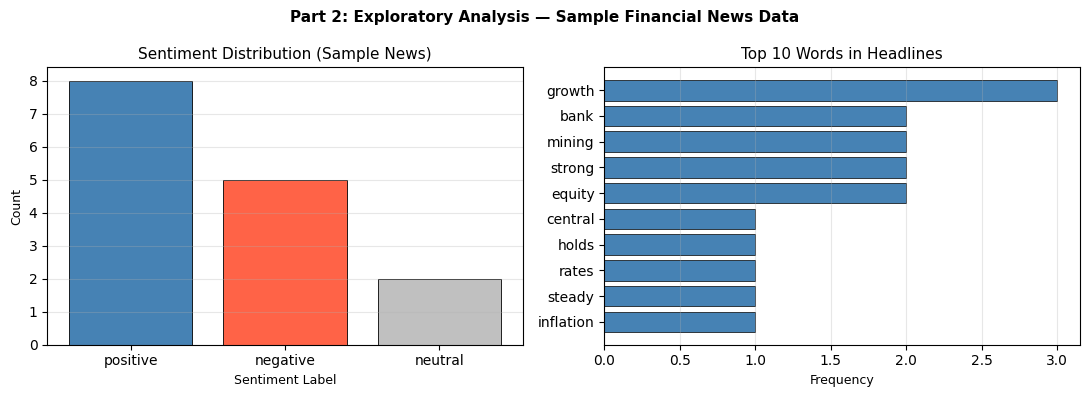

Part 2 EDA chart saved: figure3_part2_eda.png


In [13]:
# EDA charts for Part 2
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Sentiment bar chart
colors_map = {'positive':'steelblue','negative':'tomato','neutral':'silver'}
bar_colors  = [colors_map[s] for s in sent_counts.index]
axes[0].bar(sent_counts.index, sent_counts.values,
            color=bar_colors, edgecolor='black', linewidth=0.6)
axes[0].set_title('Sentiment Distribution (Sample News)', fontsize=11)
axes[0].set_xlabel('Sentiment Label', fontsize=9)
axes[0].set_ylabel('Count', fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# Top word frequency
words, cnts = zip(*word_freq)
axes[1].barh(list(words), list(cnts), color='steelblue',
             edgecolor='black', linewidth=0.5)
axes[1].set_title('Top 10 Words in Headlines', fontsize=11)
axes[1].set_xlabel('Frequency', fontsize=9)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Part 2: Exploratory Analysis — Sample Financial News Data', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figure3_part2_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Part 2 EDA chart saved: figure3_part2_eda.png')

---
## Notebook Complete
All outputs from this notebook are used in the written report as follows:
- **Table 1** (Pearson correlations): from Section 5 output
- **Table 2** (CV results): from Section 6 output
- **Figure 1** (ECH price + SMA14): from Section 7, file `figure1_ech_sma14.png`
- **Figure 2** (RSI14): from Section 8, file `figure2_ech_rsi14.png`
- **Part 2 code and EDA**: from Part 2 sections above